# Desafio Maker - Data Science Hackaton

## Objetivo
O presente arquivo apresenta a etapa de exploração e conhecimento dos dados utilizados no desafio técnico.

O principal objetivo desta fase é compreender a estrutura da base, identificar possíveis problemas de qualidade dos dados recebidos e definir uma estratégia de tratamento antes da realização das análises de negócio.

As análises desenvolvidas neste notebook servirão como base para o desenvolvimento da solução final em Python.

# 1. Importação das bibliotecas

Nesta seção são importadas as bibliotecas utilizadas ao longo da análise. 

Cada uma delas possui uma finalidade específica:
- **Pandas**: manipulação e análise dos dados;
- **NumPy**: operações matemáticas e tratamento numérico;
- **Matplotlib**: criação de gráficos;
- **Seaborn**: visualizações estatísticas;
- **Pathlib**: manipulação de caminhos de arquivos.


In [102]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Configuração do ambiente

Antes de iniciar a análise, algumas configurações foram definidas com a finalidade de melhorar a visualização das informações durante o decorrer do projeto.

Essas configurações não alteram a fonte original dos dados, apenas tornam a apresentação mais clara.

In [103]:
# Exibe todas as colunas dos DataFrames
pd.set_option("display.max_columns", None)

# Ajusta a quantidade máxima de linhas que aparecem
pd.set_option("display.max_rows", 100)

# Definição do tamanho padrão das figuras
plt.rcParams["figure.figsize"] = (10, 6)

# Aplica um tema padrão aos gráficos
sns.set_theme(style="whitegrid")

# 3. Carregamento dos dados

O desafio disponibilizou duas bases de dados em um único arquivo Excel.

As planilhas serão carregadas separadamente para facilitar a exploração individual de cada conjunto de dados e permitir cruzamentos posteriores durante a análise.

In [104]:
# Variável constante com o caminho do arquivo disponibilizado no desafio
CAMINHO_DADOS = Path('../data/db_atlas.xlsx')

# Carrega o histórico de cotações
historico_cotacoes = pd.read_excel(
    CAMINHO_DADOS,
    sheet_name="HISTORICO_COTACOES"
)

# Carrega as informações da frota
frota_ativos = pd.read_excel(
    CAMINHO_DADOS,
    sheet_name="FROTA_ATIVOS"
)

# 4. Compreendendo a base

Antes de realizar qualquer tipo de alteração, é importante compreender a estrutura das bases originalmente disponibilizadas.

Nesta parte, serão respondidos questionamentos como:
- Qual a quantidade total de registros existentes?
- Quais dados estão disponíveis?
- Quais os tipos de cada variável
- Existems possíveis inconsitências já perceptíveis?

In [105]:
display(historico_cotacoes.head())

display(frota_ativos.head())

,Client_Name,Quote_Date,Quote_ID,Close_Date,Days_To_Close,Serial_ID,Amount_BRL,Stage
0,Rosberg Energy 429,2023-09-05 00:27:21,QT-100000,2023-10-12 00:27:21,NaN,SN-10144,42865.48,Perdido
1,Mansell Agro 996,2023-08-22 07:54:37,QT-100001,2023-10-03 07:54:37,42.0,SN-10253,42139.31,Perdido
2,Verstappen Logistics 715,2023-07-28 09:59:33,QT-100002,2023-07-29 09:59:33,1.0,SN-10130,44611.83,Ganho
3,Clark Dynamics 461,2023-09-12 08:33:55,QT-100003,2023-10-23 08:33:55,41.0,SN-10249,39920.19,Perdido
4,Stewart Agro 422,06/02/2024,QT-100004,2024-03-15 07:46:46,38.0,SN-10463,26830.45,Ganho


,Serial_ID,F1_Model,Solution_Type,Acquisition_Cost_BRL,Accumulated_Depreciation_BRL,Total_Maintenance_Cost_BRL
0,SN-10000,MP4/4,Solução 1,237454.01,223825.85,246761.35
1,SN-10001,MP4/4,Solução 1,259865.85,213974.27,180242.10
2,SN-10002,MP4/4,Solução 1,205808.36,191386.63,197713.71
3,SN-10003,MP4/4,Solução 1,270807.26,217481.97,320079.53
4,SN-10004,MP4/4,Solução 1,283244.26,235616.99,200847.09


In [106]:
print(
    f"Histórico de cotações: {historico_cotacoes.shape[0]} registros e {historico_cotacoes.shape[1]} colunas."
)

print(
    f"Frota de ativos: {frota_ativos.shape[0]} registros e {frota_ativos.shape[1]} colunas."
)

Histórico de cotações: 6000 registros e 8 colunas.
Frota de ativos: 580 registros e 6 colunas.


## Interpretação

A consulta da dimensão permite compreender o volume de dados disponível para análise. Essa informação também auxilia na escolha de estratégias de tratamento e visualização.

In [107]:
historico_cotacoes.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Client_Name    6000 non-null   str           
 1   Quote_Date     6000 non-null   object        
 2   Quote_ID       6000 non-null   str           
 3   Close_Date     6000 non-null   datetime64[us]
 4   Days_To_Close  5682 non-null   float64       
 5   Serial_ID      6000 non-null   str           
 6   Amount_BRL     6000 non-null   float64       
 7   Stage          6000 non-null   str           
dtypes: datetime64[us](1), float64(2), object(1), str(4)
memory usage: 375.1+ KB


In [108]:
frota_ativos.info()

<class 'pandas.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Serial_ID                     580 non-null    str    
 1   F1_Model                      580 non-null    str    
 2   Solution_Type                 580 non-null    str    
 3   Acquisition_Cost_BRL          580 non-null    float64
 4   Accumulated_Depreciation_BRL  580 non-null    float64
 5   Total_Maintenance_Cost_BRL    580 non-null    float64
dtypes: float64(3), str(3)
memory usage: 27.3 KB


### Interpretação

Observa-se que as bases possuem colunas numéricas, categóricas e temporais.

Também é possível identificar valor ausentes ou que diferem do padrão estabelecido pelo restante dos dados registrados, aspecto que será investigado na próxima etapa.

# 5. Avaliação da qualidade dos dados

Esta etapa busca encontrar possíveis problemas que possam comprometer a confiabilidade das análises futuras.

Serão avalliados os seguintes aspectos:
- Valores ausentes;
- Registros duplicados;
- Tipos de dados;
- Estatísticas descritivas;
- Valores únicos em variáveis categóricas;
- Consistência entre os registros.

## 5.1 Verificação de valores ausentes
Valores ausentes podem destacar falhas no processo de coleta, integração ou armazenamento dos dados.

Nesta seção, será identificado o número absoluto e o percentual de valores nulos em cada coluna de ambas as bases.


In [109]:
def analisar_valores_ausentes(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Retorna a quantidade e o percentual de valores ausentes por coluna.
    """

    valores_ausentes = dataframe.isna().sum()

    percentual_ausentes = (
        dataframe.isna().mean() * 100
    ).round(2)

    resultado = pd.DataFrame({
        "Valores ausentes": valores_ausentes,
        "Percentual (%)": percentual_ausentes
    })

    return resultado.sort_values(
        by="Percentual (%)",
        ascending=False
    )

In [110]:
print("Histórico de Cotações")
display(analisar_valores_ausentes(historico_cotacoes))

Histórico de Cotações


,Valores ausentes,Percentual (%)
Days_To_Close,318,5.3
Client_Name,0,0.0
Quote_ID,0,0.0
Quote_Date,0,0.0
Close_Date,0,0.0
Serial_ID,0,0.0
Amount_BRL,0,0.0
Stage,0,0.0


In [111]:
print("Frota de Ativos")
display(analisar_valores_ausentes(frota_ativos))

Frota de Ativos


,Valores ausentes,Percentual (%)
Serial_ID,0,0.0
F1_Model,0,0.0
Solution_Type,0,0.0
Acquisition_Cost_BRL,0,0.0
Accumulated_Depreciation_BRL,0,0.0
Total_Maintenance_Cost_BRL,0,0.0


## Interpretação

Foi possível identificar que a coluna `Days_To_Close` do histórico de transações apresenta valores ausentes.

Futuramente será avaliado se há possibilidade de recuperar esses registros, tratados ou removidos sem comprometer as análises de negócio.

## Verificação de registros duplicados

Registros duplicados podem afetar os insights egerar distorções em indicadores como quantidade de cotações, taxa de conversão e faturamento.

Por essas razões, será avaliada a existência de linhas completamente duplicadas nas duas bases.

In [112]:
def contar_duplicados(dataframe: pd.DataFrame) -> int:
    """
    Retorna a quantidade de registros duplicados.
    """
    return dataframe.duplicated().sum()

In [113]:
print(
    f"Duplicados no histórico: {contar_duplicados(historico_cotacoes)}"
)

print(
    f"Duplicados na frota: {contar_duplicados(frota_ativos)}"
)

Duplicados no histórico: 0
Duplicados na frota: 0


## 5.3 Estatísticas descritivas

As estatísticas descritivas permitem compreender a distribuição das variáveis numéricas.

Serão analisados indicadores como média, desvio padrão, valores mínimos, máximos e quartis.

In [114]:
display(
    historico_cotacoes.describe().T
)

,count,mean,min,25%,50%,75%,max,std
Close_Date,6000,2025-02-10 21:55:27.385166,2023-07-25 09:33:19,2024-05-12 19:20:57.250000,2025-02-13 06:57:05,2025-11-11 18:36:38.500000,2026-10-30 01:17:20,NaN
Days_To_Close,5682.0,24.831749,0.0,6.0,20.0,37.0,174.0,22.269995
Amount_BRL,6000.0,50419.1581,-144294.072538,19447.56,30783.225,42134.1875,9999999.99,407679.091778


In [115]:
display(
    frota_ativos.describe().T
)

,count,mean,std,min,25%,50%,75%,max
Acquisition_Cost_BRL,580.0,173038.975552,54566.271942,100756.29,133873.8725,162772.925,192085.395,349005.39
Accumulated_Depreciation_BRL,580.0,85666.261552,49299.568321,15016.24,56048.8925,72847.080,95120.050,278623.92
Total_Maintenance_Cost_BRL,580.0,53369.216914,57659.842276,3126.50,23298.6150,36942.415,54170.320,320079.53


### Interpretação

A análise estatística revelou valores extremos na coluna `Amount_BRL`, incluindo propostas com valores negativos e uma proposta com valor significativamente superior ao restante da distribuição.

Antes de qualquer tratamento, esses registros serão investigados individualmente para verificar se representam erros de preenchimento ou situações válidas do negócio.

## 5.4 Análise das variáveis categóricas

Antes de realizar agrupamentos, é importante compreender os valores existentes nas variáveis categóricas.

Essa análise permite identificar categorias inconsistentes e possíveis problemas de padronização.

In [116]:
def analisar_variavel_categorica(
    dataframe: pd.DataFrame,
    coluna: str
) -> None:
    """
    Exibe a frequência de cada categoria.
    """

    display(
        dataframe[coluna]
        .value_counts(dropna=False)
    )

In [117]:
analisar_variavel_categorica(
    historico_cotacoes,
    "Stage"
)

Stage
Perdido     2882
Ganho       2216
Perdido      137
ganho        135
lost         133
 WON         128
GAnho        125
W0n          123
 Not Won     121
Name: count, dtype: int64

# 6. Investigação das Inconsistências Encontradas

A etapa de avaliação da qualidade dos dados identificou algumas inconsistências que podem impactar diretamente os resultados das análises.

Antes de aplicar qualquer transformação, cada uma delas será investigada individualmente para compreender sua origem e definir a estratégia de tratamento mais adequada.

As principais inconsistências encontradas foram:

- Valores ausentes na coluna `Days_To_Close`;
- Falta de padronização na coluna `Stage`.

## 6.1 Investigação dos valores ausentes em `Days_To_Close`

A coluna `Days_To_Close` apresentou registros sem informação durante a avaliação da qualidade dos dados.

Antes de decidir pela remoção ou preenchimento desses valores, é importante verificar se sua ausência está relacionada a alguma regra de negócio, como cotações ainda em andamento ou não concluídas.

In [118]:
historico_cotacoes[
    ["Quote_Date", "Close_Date"]
].dtypes

Quote_Date            object
Close_Date    datetime64[us]
dtype: object

In [119]:
# Converte a coluna de texto para data utilizando o padrão dia/mês/ano

historico_cotacoes["Quote_Date"] = pd.to_datetime(
    historico_cotacoes["Quote_Date"],
    dayfirst=True
)

In [120]:
historico_cotacoes[
    ["Quote_Date", "Close_Date"]
].dtypes

Quote_Date    datetime64[us]
Close_Date    datetime64[us]
dtype: object

In [121]:
historico_cotacoes["Days_To_Close"] = (
    historico_cotacoes["Close_Date"] - historico_cotacoes["Quote_Date"]
).dt.days

In [122]:
historico_cotacoes.head()

,Client_Name,Quote_Date,Quote_ID,Close_Date,Days_To_Close,Serial_ID,Amount_BRL,Stage
0,Rosberg Energy 429,2023-09-05 00:27:21,QT-100000,2023-10-12 00:27:21,37,SN-10144,42865.48,Perdido
1,Mansell Agro 996,2023-08-22 07:54:37,QT-100001,2023-10-03 07:54:37,42,SN-10253,42139.31,Perdido
2,Verstappen Logistics 715,2023-07-28 09:59:33,QT-100002,2023-07-29 09:59:33,1,SN-10130,44611.83,Ganho
3,Clark Dynamics 461,2023-09-12 08:33:55,QT-100003,2023-10-23 08:33:55,41,SN-10249,39920.19,Perdido
4,Stewart Agro 422,2024-02-06 00:00:00,QT-100004,2024-03-15 07:46:46,38,SN-10463,26830.45,Ganho


## Interpretação

A coluna `Quote_Date` estava armazenada como texto (`object`), impossibilitando operações envolvendo datas.

Durante a inspeção foi identificado que os registros seguem o padrão `dd/mm/yyyy`. Dessa forma, a conversão foi realizada utilizando um formato explícito (`%d/%m/%Y`), eliminando ambiguidades na interpretação das datas e garantindo a consistência dos cálculos temporais.

A coluna `Dias_Calculados` serve temporariamente para mostrar a versão Corrigida de `Days_To_Close`

## 6.2 Padronização da coluna `Stage`

A coluna `Stage` representa o resultado final de cada cotação e será utilizada em diversos indicadores, como taxa de conversão e análises de desempenho.

Durante a inspeção dos dados foram identificadas diferentes representações para um mesmo status, incluindo diferenças de idioma, capitalização, espaços em branco e erros de digitação.

Antes da padronização, foram listados todos os valores distintos presentes na coluna.

In [124]:
# Listando todos os diferentes registros de categoria na coluna stage

categorias_stage = (
    historico_cotacoes["Stage"]
    .unique()
)

categorias_stage

<StringArray>
[ 'Perdido',    'Ganho', 'Perdido ',     ' WON',    'GAnho',     'lost',
 ' Not Won',    'ganho',      'W0n']
Length: 9, dtype: str

### Interpretação

Foram identificadas nove maneiras diferentes de representar os registros do status das cotações.

Embora existam apenas dois estados de negócio ("Ganho" e "Perdido"), a coluna apresenta inconsistências como:

- utilização simultânea de português e inglês;
- diferenças entre letras maiúsculas e minúsculas;
- espaços em branco no início e no final dos textos;
- erro de digitação (`W0n`, utilizando o número zero em vez da letra "O").

Essas inconsistências fariam com que registros pertencentes à mesma categoria fossem analisados separadamente, comprometendo indicadores como a taxa de conversão.

Dessa forma, será realizada a padronização da coluna antes das análises exploratórias.

In [125]:
# A padronização será realizada em três etapas:
# 1. Remover espaços em branco no início e no final dos textos;
# 2. Uniformizar a capitalização para facilitar a comparação entre valores;
# 3. Mapear todas as representações equivalentes para apenas duas categorias: "Ganho" e "Perdido".

# Remove espaços em branco excedentes
historico_cotacoes["Stage"] = historico_cotacoes["Stage"].str.strip()

# Padroniza a escrita para letras minúsculas
historico_cotacoes["Stage"] = historico_cotacoes["Stage"].str.lower()

# Mapeia todas as variações para uma representação única
MAPEAMENTO_STAGE = {
    "ganho": "Ganho",
    "won": "Ganho",
    "w0n": "Ganho",
    "perdido": "Perdido",
    "lost": "Perdido",
    "not won": "Perdido",
}

historico_cotacoes["Stage"] = historico_cotacoes["Stage"].replace(MAPEAMENTO_STAGE)

## 6.3 Identificação e tratamento de outliers

A coluna `Amount_BRL` apresentou valores significativamente diferentes da distribuição geral.

Para identificar esses registros de forma objetiva, foi utilizado o método do Intervalo Interquartil (IQR), amplamente empregado na detecção de valores extremos.

Após a identificação, os registros foram analisados individualmente antes da definição da estratégia de tratamento.

In [126]:
# Calcula os quartis da distribuição
q1 = historico_cotacoes["Amount_BRL"].quantile(0.25)
q3 = historico_cotacoes["Amount_BRL"].quantile(0.75)

# Calcula o Intervalo Interquartil (IQR)
iqr = q3 - q1

# Define os limites para identificação de outliers
limite_inferior = q1 - (1.5 * iqr)
limite_superior = q3 + (1.5 * iqr)

# Aplica Winsorização, limitando os valores extremos aos limites calculados
historico_cotacoes["Amount_BRL"] = historico_cotacoes["Amount_BRL"].clip(
    lower=limite_inferior,
    upper=limite_superior
)

# 7. Validação da Limpeza

Após a aplicação dos tratamentos, foi realizada uma nova verificação da base para confirmar que as transformações produziram os resultados esperados.

Essas etapa garante a integridade dos dados antes do início da análise exploratória

## 7.1 Verificação dos tipos de dados


In [129]:
historico_cotacoes.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Client_Name    6000 non-null   str           
 1   Quote_Date     6000 non-null   datetime64[us]
 2   Quote_ID       6000 non-null   str           
 3   Close_Date     6000 non-null   datetime64[us]
 4   Days_To_Close  6000 non-null   int64         
 5   Serial_ID      6000 non-null   str           
 6   Amount_BRL     6000 non-null   float64       
 7   Stage          6000 non-null   str           
dtypes: datetime64[us](2), float64(1), int64(1), str(4)
memory usage: 375.1 KB


## 7.2 Verificação da coluna `Stage`

In [130]:
historico_cotacoes["Stage"].value_counts()

Stage
Perdido    3273
Ganho      2727
Name: count, dtype: int64

## 7.3 Verificação dos outliers de `Aumount_BRL`

In [131]:
# Estatísticas após o tratamento dos outliers
historico_cotacoes["Amount_BRL"].describe()

count     6000.000000
mean     31755.149357
std      19206.999644
min     -14582.381250
25%      19447.560000
50%      30783.225000
75%      42134.187500
max      76164.128750
Name: Amount_BRL, dtype: float64

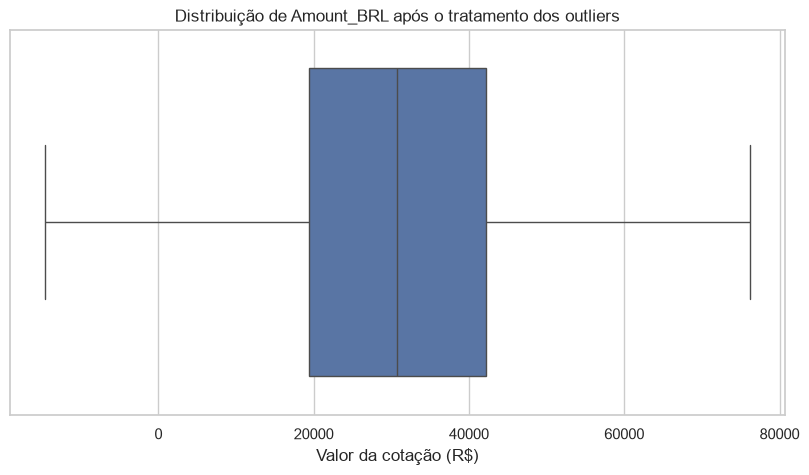

In [132]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=historico_cotacoes["Amount_BRL"]
)

plt.title("Distribuição de Amount_BRL após o tratamento dos outliers")
plt.xlabel("Valor da cotação (R$)")

plt.show()

# 8. Análise Exploratória dos Dados (EDA)

## 8.1 Visão Geral das Cotações

Antes de iniciar as análises específicas, é importante compreender o panorama geral da base.

Nesta estapa serão definidos indicadores básicos da operação comercial, como quantidade de propostas, clientes e equipamentos distintos

In [171]:
# Indicadores gerais

total_propostas = historico_cotacoes["Quote_ID"].nunique()

total_clientes = historico_cotacoes["Client_Name"].nunique()

tempo_medio_geral = historico_cotacoes["Days_To_Close"].mean()

win_rate_geral = (
    historico_cotacoes["Stage"]
    .eq("Ganho")
    .mean()
    * 100
)

print(f"Total de propostas: {total_propostas}")
print(f"Total de clientes: {total_clientes}")
print(f"Tempo médio: {tempo_medio_geral:.2f} dias")
print(f"Win Rate: {win_rate_geral:.2f}%")

Total de propostas: 6000
Total de clientes: 3415
Tempo médio: 24.95 dias
Win Rate: 45.45%


## 8.2 Tempo Médio de Fechamento das Propostas

O tempo necessário para converter uma proposta representa um importante indicador operacional.

Nesta etapa será calculado o tempo médio de fechamento das propostas, que servirá como referência para identificar clientes e segmentos com desempenho superior à média.

In [135]:
# Estatísticas descritivas da coluna Days_To_Close
historico_cotacoes["Days_To_Close"].describe()

count    6000.000000
mean       24.951667
std        22.293500
min         0.000000
25%         6.000000
50%        20.000000
75%        37.000000
max       174.000000
Name: Days_To_Close, dtype: float64

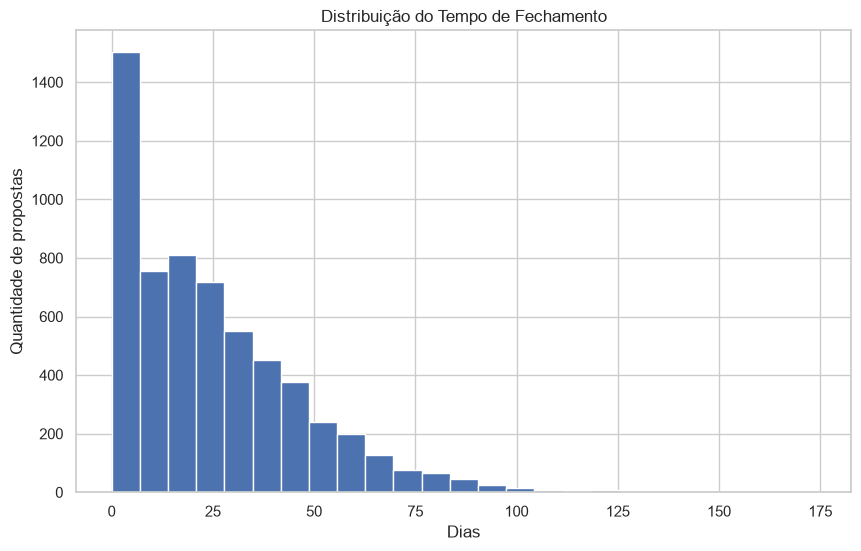

In [136]:
plt.figure(figsize=(10,6))

plt.hist(
    historico_cotacoes["Days_To_Close"].dropna(),
    bins=25
)

plt.title("Distribuição do Tempo de Fechamento")
plt.xlabel("Dias")
plt.ylabel("Quantidade de propostas")

plt.show()

In [137]:
tempo_medio = historico_cotacoes["Days_To_Close"].mean()

print(f"Tempo médio de fechamento: {tempo_medio:.2f} dias")

Tempo médio de fechamento: 24.95 dias


## 8.3 Taxa Geral de Conversão (Win Rate)

A taxa de conversão representa o percentual de propostas que foram efetivamente convertidas em vendas.

Esse indicador servirá como referência para identificar clientes e segmentos com desempenho superior à média.

In [139]:
# Calcula a quantidade de propostas por status

resultado = historico_cotacoes["Stage"].value_counts()

resultado

Stage
Perdido    3273
Ganho      2727
Name: count, dtype: int64

In [141]:
win_rate = (
    historico_cotacoes["Stage"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

win_rate

Stage
Perdido    54.55
Ganho      45.45
Name: proportion, dtype: float64

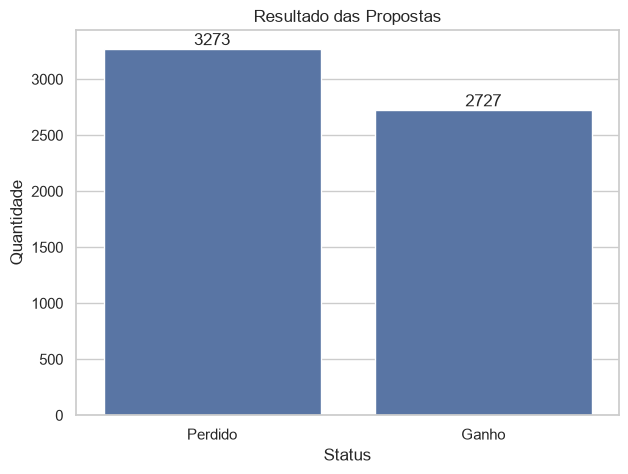

In [142]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=historico_cotacoes,
    x="Stage"
)

plt.title("Resultado das Propostas")
plt.xlabel("Status")
plt.ylabel("Quantidade")

for barra in ax.patches:
    altura = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f"{int(altura)}",
        ha="center",
        va="bottom"
    )

plt.show()

## 8.4 Avaliação do desempenho por cliente

A Diretoria suspeita que determinados clientes apresentam desempenho superior ao restante da operação.

Para validar essa hipótese, serão calculados três indicadores para cada cliente:

- quantidade de propostas;
- tempo médio de fechamento;
- taxa de conversão (Win Rate).

In [143]:
# Agrupa as informações por cliente
analise_clientes = (
    historico_cotacoes
    .groupby("Client_Name")
    .agg(
        Quantidade_Propostas=("Quote_ID", "count"),

        Tempo_Medio_Dias=("Days_To_Close", "mean"),

        Win_Rate=("Stage", lambda x: (x == "Ganho").mean() * 100)
    )
    .round(2)
)

In [159]:
clientes_relevantes = analise_clientes[
    analise_clientes["Quantidade_Propostas"] >= 10
].copy()

In [160]:
clientes_relevantes["Acima_WinRate"] = (
    clientes_relevantes["Win_Rate"] > win_rate_geral
)

clientes_relevantes["Abaixo_Tempo"] = (
    clientes_relevantes["Tempo_Medio_Dias"] < tempo_medio_geral
)

In [162]:
# Média geral da operação
win_rate_geral = (
    historico_cotacoes["Stage"]
    .eq("Ganho")
    .mean()
    * 100
)

tempo_medio_geral = historico_cotacoes["Days_To_Close"].mean()

In [147]:
clientes_destaque = clientes_destaque.copy()

clientes_destaque["Acima_WinRate"] = (
    clientes_destaque["Win_Rate"] > win_rate_geral
)

clientes_destaque["Abaixo_Tempo"] = (
    clientes_destaque["Tempo_Medio_Dias"] < tempo_medio_geral
)

In [163]:
clientes_candidatos = clientes_relevantes[
    clientes_relevantes["Acima_WinRate"] &
    clientes_relevantes["Abaixo_Tempo"]
]

clientes_candidatos.sort_values(
    by=["Win_Rate", "Tempo_Medio_Dias"],
    ascending=[False, True]
)

,Quantidade_Propostas,Tempo_Medio_Dias,Win_Rate,Acima_WinRate,Abaixo_Tempo
Client_Name,,,,,
Rosberg Logistics 121,11,2.64,90.91,True,True
Senna Heavy Machining 614,10,3.70,90.00,True,True
Piquet Logistics 200,11,2.36,81.82,True,True
Leclerc Logistics 616,10,2.20,80.00,True,True
Raikkonen Logistics 461,10,2.30,80.00,True,True
Senna Aero 671,10,2.80,80.00,True,True
Senna Industries 496,13,2.62,69.23,True,True
Vettel Logistics 976,10,2.00,60.00,True,True
Raikkonen Agro 107,10,23.10,60.00,True,True


### 8.4.1. Identificação do Segmento do Cliente

O nome dos clientes apresenta um padrão composto por três partes:

- Nome fictício;
- Segmento de atuação;
- Identificador numérico.

A partir desse padrão, foi extraído o segmento de cada cliente para avaliar se determinados mercados apresentam maior taxa de conversão e menor tempo de fechamento das propostas.

In [164]:
# Função para extrair corretamente o segmento do cliente
def extrair_segmento(nome):
    partes = nome.split()

    if len(partes) >= 4 and partes[1] == "Heavy":
        return "Heavy Machining"

    return partes[1]


historico_cotacoes["Segmento"] = (
    historico_cotacoes["Client_Name"]
    .apply(extrair_segmento)
)

In [165]:
historico_cotacoes[
    ["Client_Name", "Segmento"]
].sample(10, random_state=42)

,Client_Name,Segmento
1782,Raikkonen Energy 870,Energy
3917,Alonso Industries 99,Industries
221,Hakkinen Logistics 937,Logistics
2135,Verstappen Corp 536,Corp
5224,Perez Aero 201,Aero
1168,Leclerc Industries 677,Industries
879,Rosberg Aero 283,Aero
156,Piquet Energy 537,Energy
1657,Sainz Energy 269,Energy
323,Hakkinen Heavy Machining 536,Heavy Machining


### 8.4.2. Desempenho por Segmento

Com o segmento identificado, serão calculados indicadores comerciais para cada grupo, permitindo identificar mercados com maior potencial de conversão.

In [166]:
analise_segmentos = (
    historico_cotacoes
    .groupby("Segmento")
    .agg(
        Quantidade_Propostas=("Quote_ID", "count"),
        Tempo_Medio_Dias=("Days_To_Close", "mean"),
        Win_Rate=("Stage", lambda x: (x == "Ganho").mean() * 100)
    )
    .round(2)
)

analise_segmentos

,Quantidade_Propostas,Tempo_Medio_Dias,Win_Rate
Segmento,,,
Aero,763,30.23,36.57
Agro,758,27.78,37.20
Corp,741,27.07,36.17
Dynamics,722,27.89,33.93
Energy,765,28.73,36.86
Heavy Machining,681,28.35,67.55
Industries,782,28.76,33.76
Logistics,788,2.05,82.11


In [168]:
segmentos_destaque = analise_segmentos[
    (analise_segmentos["Win_Rate"] > win_rate_geral) &
    (analise_segmentos["Tempo_Medio_Dias"] < tempo_medio_geral)
]

segmentos_destaque

,Quantidade_Propostas,Tempo_Medio_Dias,Win_Rate
Segmento,,,
Logistics,788,2.05,82.11


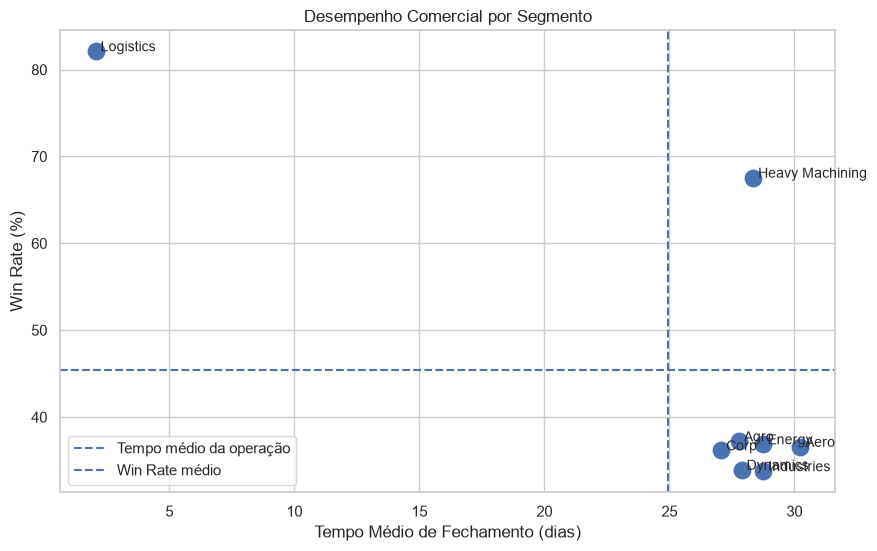

In [169]:
plt.figure(figsize=(10, 6))

plt.scatter(
    analise_segmentos["Tempo_Medio_Dias"],
    analise_segmentos["Win_Rate"],
    s=140
)

for segmento, linha in analise_segmentos.iterrows():

    plt.text(
        linha["Tempo_Medio_Dias"] + 0.2,
        linha["Win_Rate"],
        segmento,
        fontsize=10
    )

plt.axvline(
    tempo_medio_geral,
    linestyle="--",
    linewidth=1.5,
    label="Tempo médio da operação"
)

plt.axhline(
    win_rate_geral,
    linestyle="--",
    linewidth=1.5,
    label="Win Rate médio"
)

plt.xlabel("Tempo Médio de Fechamento (dias)")
plt.ylabel("Win Rate (%)")
plt.title("Desempenho Comercial por Segmento")

plt.legend()

plt.show()

## 8.4.3. Consolidação dos Perfis Identificados

Após as análises por cliente e por segmento, será verificado se os melhores clientes pertencem a um mesmo perfil de mercado ou se existem grupos distintos com elevado desempenho comercial.

Essa consolidação permitirá responder objetivamente à hipótese proposta pela Diretoria.

In [170]:
# Relaciona os clientes candidatos ao segmento identificado
perfil_clientes = (
    historico_cotacoes[
        ["Client_Name", "Segmento"]
    ]
    .drop_duplicates()
    .merge(
        clientes_candidatos.reset_index(),
        on="Client_Name"
    )
)

perfil_clientes.sort_values(
    by=["Segmento", "Win_Rate"],
    ascending=[True, False]
)

,Client_Name,Segmento,Quantidade_Propostas,Tempo_Medio_Dias,Win_Rate,Acima_WinRate,Abaixo_Tempo
3,Senna Aero 671,Aero,10,2.80,80.00,True,True
4,Raikkonen Agro 107,Agro,10,23.10,60.00,True,True
0,Hamilton Agro 895,Agro,10,19.50,50.00,True,True
5,Senna Heavy Machining 614,Heavy Machining,10,3.70,90.00,True,True
1,Senna Industries 496,Industries,13,2.62,69.23,True,True
6,Rosberg Logistics 121,Logistics,11,2.64,90.91,True,True
9,Piquet Logistics 200,Logistics,11,2.36,81.82,True,True
7,Leclerc Logistics 616,Logistics,10,2.20,80.00,True,True
8,Raikkonen Logistics 461,Logistics,10,2.30,80.00,True,True
2,Vettel Logistics 976,Logistics,10,2.00,60.00,True,True


## 8.4.4. Influência do Valor da Proposta

Além das características dos clientes, investigou-se se o valor financeiro da proposta influencia a velocidade de conversão e a taxa de sucesso das negociações.

Para isso, os valores das propostas foram divididos em cinco faixas de tamanho semelhante utilizando quintis.

In [172]:
# Cria cinco grupos com aproximadamente a mesma quantidade de propostas
historico_cotacoes["Faixa_Valor"] = pd.qcut(
    historico_cotacoes["Amount_BRL"],
    q=5,
    duplicates="drop"
)

In [173]:
analise_valor = (
    historico_cotacoes
    .groupby("Faixa_Valor")
    .agg(
        Quantidade_Propostas=("Quote_ID", "count"),

        Tempo_Medio_Dias=("Days_To_Close", "mean"),

        Win_Rate=("Stage", lambda x: (x == "Ganho").mean() * 100)
    )
    .round(2)
)

analise_valor

,Quantidade_Propostas,Tempo_Medio_Dias,Win_Rate
Faixa_Valor,,,
"(-14582.382, 17332.42]",1200,24.34,43.00
"(17332.42, 26035.668]",1200,25.82,42.33
"(26035.668, 35295.81]",1200,23.62,40.42
"(35295.81, 44390.292]",1200,24.80,41.83
"(44390.292, 76164.129]",1200,26.18,59.67


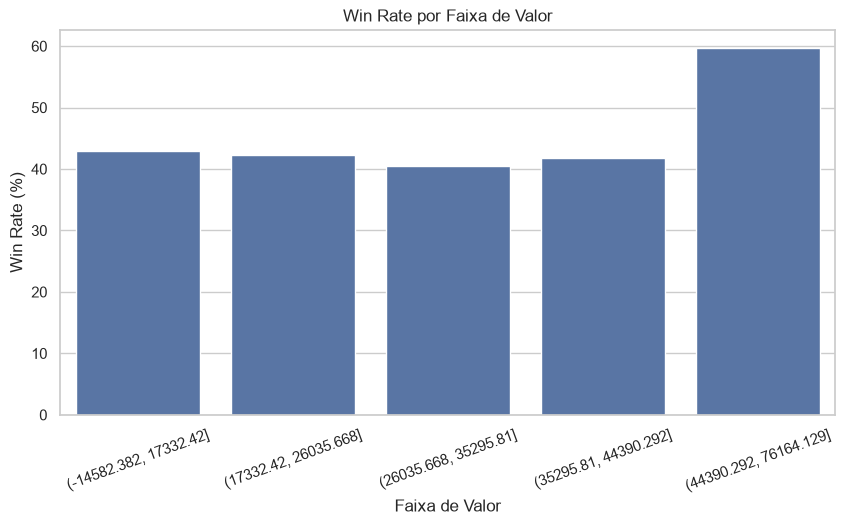

In [174]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=analise_valor.reset_index(),
    x="Faixa_Valor",
    y="Win_Rate"
)

plt.xticks(rotation=20)

plt.ylabel("Win Rate (%)")

plt.xlabel("Faixa de Valor")

plt.title("Win Rate por Faixa de Valor")

plt.show()

## 8.4.5. Relação entre Tempo de Fechamento e Taxa de Conversão

Nesta etapa foi investigado se propostas concluídas mais rapidamente apresentam maior probabilidade de conversão.

In [175]:
# Cria faixas de tempo
historico_cotacoes["Faixa_Tempo"] = pd.cut(

    historico_cotacoes["Days_To_Close"],

    bins=[0,5,15,30,60,180],

    labels=[
        "0-5 dias",
        "6-15 dias",
        "16-30 dias",
        "31-60 dias",
        "Mais de 60 dias"
    ],

    include_lowest=True
)

In [176]:
analise_tempo = (
    historico_cotacoes
    .groupby("Faixa_Tempo")
    .agg(
        Quantidade=("Quote_ID","count"),

        Win_Rate=("Stage", lambda x:(x=="Ganho").mean()*100)
    )
    .round(2)
)

analise_tempo

,Quantidade,Win_Rate
Faixa_Tempo,,
0-5 dias,1405,71.39
6-15 dias,1081,38.21
16-30 dias,1558,36.78
31-60 dias,1517,37.05
Mais de 60 dias,439,40.09


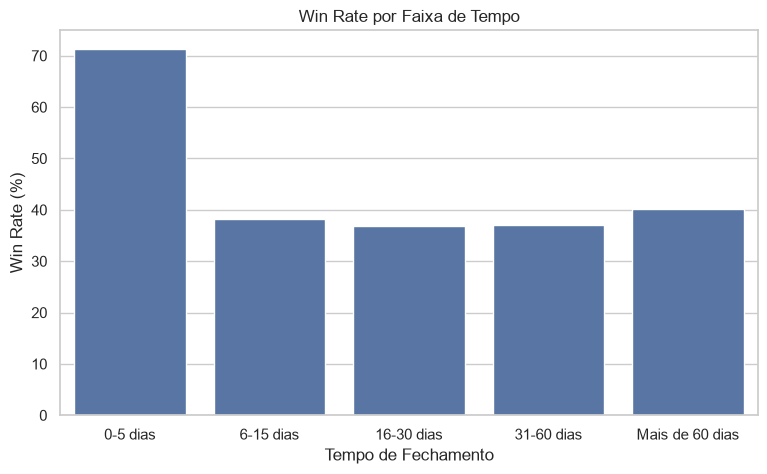

In [177]:
plt.figure(figsize=(9,5))

sns.barplot(

    data=analise_tempo.reset_index(),

    x="Faixa_Tempo",

    y="Win_Rate"

)

plt.ylabel("Win Rate (%)")

plt.xlabel("Tempo de Fechamento")

plt.title("Win Rate por Faixa de Tempo")

plt.show()

### Influência do valor da proposta

A análise por quintis de valor mostrou que as propostas pertencentes à faixa de maior valor apresentam Win Rate de 59,67%, superior à média geral de 45,45%.

Entretanto, o tempo médio de fechamento desse grupo é de 26,18 dias, ligeiramente superior à média geral de 24,95 dias.

Portanto, embora propostas de maior valor apresentem maior probabilidade de conversão, esse grupo não atende simultaneamente aos critérios de alta conversão e fechamento rápido estabelecidos pela Diretoria, não sendo classificado como uma das oportunidades procuradas.

## 8.4.6. Investigação das Conversões Rápidas

A análise do tempo de fechamento revelou que propostas concluídas em até 5 dias apresentam Win Rate de 71,39%, significativamente superior à taxa geral de 45,45%.

Esse resultado indica a existência de um comportamento comercial específico entre as negociações de curta duração.

Para compreender quais perfis estão associados a esse desempenho, serão analisados os clientes e segmentos presentes nas propostas concluídas em até 5 dias.

In [178]:
# Seleciona propostas concluídas em até 5 dias
cotacoes_rapidas = historico_cotacoes[
    historico_cotacoes["Days_To_Close"] <= 5
].copy()

print(f"Quantidade de propostas rápidas: {len(cotacoes_rapidas)}")

Quantidade de propostas rápidas: 1405


In [179]:
# Analisa o desempenho das conversões rápidas por segmento
perfil_conversao_rapida = (
    cotacoes_rapidas
    .groupby("Segmento")
    .agg(
        Quantidade_Propostas=("Quote_ID", "count"),
        Tempo_Medio_Dias=("Days_To_Close", "mean"),
        Win_Rate=("Stage", lambda x: (x == "Ganho").mean() * 100)
    )
    .round(2)
    .sort_values(
        by=["Win_Rate", "Quantidade_Propostas"],
        ascending=[False, False]
    )
)

perfil_conversao_rapida

,Quantidade_Propostas,Tempo_Medio_Dias,Win_Rate
Segmento,,,
Logistics,788,2.05,82.11
Heavy Machining,85,3.34,69.41
Corp,109,3.40,61.47
Industries,114,3.35,60.53
Dynamics,86,3.15,55.81
Agro,86,3.41,52.33
Aero,66,3.44,50.00
Energy,71,3.38,49.30


In [180]:
# Quantidade total de propostas por segmento
total_por_segmento = (
    historico_cotacoes
    .groupby("Segmento")["Quote_ID"]
    .count()
)

# Quantidade de propostas fechadas em até 5 dias
rapidas_por_segmento = (
    cotacoes_rapidas
    .groupby("Segmento")["Quote_ID"]
    .count()
)

# Calcula a proporção de propostas rápidas dentro de cada segmento
proporcao_rapidas = (
    rapidas_por_segmento
    .div(total_por_segmento)
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

proporcao_rapidas

Segmento
Logistics          100.00
Corp                14.71
Industries          14.58
Heavy Machining     12.48
Dynamics            11.91
Agro                11.35
Energy               9.28
Aero                 8.65
Name: Quote_ID, dtype: float64

In [181]:
# Analisa clientes com volume representativo dentro das conversões rápidas
clientes_rapidos = (
    cotacoes_rapidas
    .groupby("Client_Name")
    .agg(
        Quantidade_Propostas=("Quote_ID", "count"),
        Tempo_Medio_Dias=("Days_To_Close", "mean"),
        Win_Rate=("Stage", lambda x: (x == "Ganho").mean() * 100)
    )
    .round(2)
)

clientes_rapidos = (
    clientes_rapidos[
        clientes_rapidos["Quantidade_Propostas"] >= 5
    ]
    .sort_values(
        by=["Win_Rate", "Quantidade_Propostas"],
        ascending=[False, False]
    )
)

clientes_rapidos.head(20)

,Quantidade_Propostas,Tempo_Medio_Dias,Win_Rate
Client_Name,,,
Mansell Logistics 34,8,2.38,100.00
Alonso Logistics 299,7,2.29,100.00
Fangio Logistics 585,7,2.00,100.00
Raikkonen Logistics 139,7,2.29,100.00
Hakkinen Logistics 968,5,1.40,100.00
Prost Logistics 288,5,2.00,100.00
Schumacher Logistics 792,5,2.20,100.00
Senna Corp 268,5,3.60,100.00
Senna Industries 802,5,4.80,100.00


## 8.4.7. Identificação dos Perfis de Oportunidade

As análises anteriores demonstraram que o segmento `Logistics` apresenta desempenho excepcional tanto em taxa de conversão quanto em velocidade de fechamento.

Entretanto, nenhum outro segmento agregado apresentou simultaneamente os dois comportamentos.

Dessa forma, a análise foi aprofundada no nível de cliente para verificar a existência de uma segunda oportunidade comercial específica, utilizando os mesmos critérios de comparação com a operação geral.

In [182]:
# Seleciona clientes com volume mínimo representativo
clientes_oportunidade = analise_clientes[
    (analise_clientes["Quantidade_Propostas"] >= 10) &
    (analise_clientes["Win_Rate"] > win_rate_geral) &
    (analise_clientes["Tempo_Medio_Dias"] < tempo_medio_geral)
].copy()

clientes_oportunidade.sort_values(
    by=["Win_Rate", "Tempo_Medio_Dias"],
    ascending=[False, True]
)

,Quantidade_Propostas,Tempo_Medio_Dias,Win_Rate
Client_Name,,,
Rosberg Logistics 121,11,2.64,90.91
Senna Heavy Machining 614,10,3.70,90.00
Piquet Logistics 200,11,2.36,81.82
Leclerc Logistics 616,10,2.20,80.00
Raikkonen Logistics 461,10,2.30,80.00
Senna Aero 671,10,2.80,80.00
Senna Industries 496,13,2.62,69.23
Vettel Logistics 976,10,2.00,60.00
Raikkonen Agro 107,10,23.10,60.00


In [183]:
# Relaciona cada cliente ao seu segmento
segmento_cliente = (
    historico_cotacoes[
        ["Client_Name", "Segmento"]
    ]
    .drop_duplicates()
)

clientes_oportunidade = (
    clientes_oportunidade
    .reset_index()
    .merge(
        segmento_cliente,
        on="Client_Name",
        how="left"
    )
)

# Investiga oportunidades que não pertencem ao perfil Logistics
segundo_perfil_candidatos = (
    clientes_oportunidade[
        clientes_oportunidade["Segmento"] != "Logistics"
    ]
    .sort_values(
        by=["Win_Rate", "Tempo_Medio_Dias"],
        ascending=[False, True]
    )
)

segundo_perfil_candidatos

,Client_Name,Quantidade_Propostas,Tempo_Medio_Dias,Win_Rate,Segmento
7,Senna Heavy Machining 614,10,3.70,90.00,Heavy Machining
6,Senna Aero 671,10,2.80,80.00,Aero
8,Senna Industries 496,13,2.62,69.23,Industries
3,Raikkonen Agro 107,10,23.10,60.00,Agro
0,Hamilton Agro 895,10,19.50,50.00,Agro


### Consideração sobre representatividade

Os dois perfis identificados apresentam desempenho significativamente superior aos indicadores gerais da operação. Entretanto, existe uma diferença importante em relação à quantidade de observações.

O segmento `Logistics` apresenta 788 propostas, fornecendo evidência robusta de um padrão comercial consistente.

Já o segundo perfil identificado possui uma quantidade consideravelmente menor de observações. Portanto, apesar do desempenho expressivo, essa oportunidade deve ser interpretada como um sinal comercial relevante a ser acompanhado e validado com novos dados.

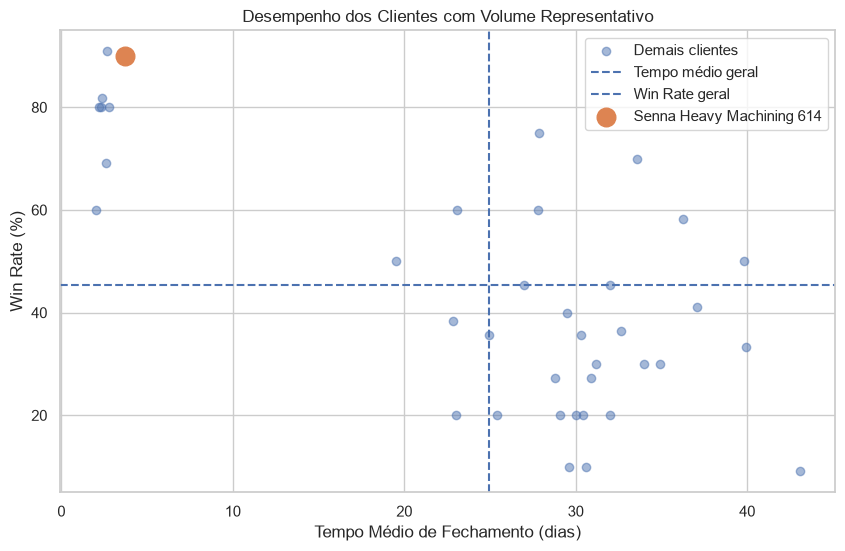

In [184]:
# Perfis que serão destacados na análise
perfis_destaque = analise_clientes.loc[
    ["Senna Heavy Machining 614"]
]

plt.figure(figsize=(10, 6))

# Todos os clientes com volume mínimo
plt.scatter(
    clientes_relevantes["Tempo_Medio_Dias"],
    clientes_relevantes["Win_Rate"],
    alpha=0.5,
    label="Demais clientes"
)

# Benchmark da operação
plt.axvline(
    tempo_medio_geral,
    linestyle="--",
    label="Tempo médio geral"
)

plt.axhline(
    win_rate_geral,
    linestyle="--",
    label="Win Rate geral"
)

# Destaca o segundo perfil
plt.scatter(
    perfis_destaque["Tempo_Medio_Dias"],
    perfis_destaque["Win_Rate"],
    s=180,
    label="Senna Heavy Machining 614"
)

plt.xlabel("Tempo Médio de Fechamento (dias)")
plt.ylabel("Win Rate (%)")
plt.title("Desempenho dos Clientes com Volume Representativo")

plt.legend()
plt.show()

## 9. Principais Oportunidades Identificadas

A análise do histórico de cotações revelou dois perfis comerciais com desempenho significativamente superior aos indicadores gerais da operação.

### 9.1. Segmento Logistics

O segmento `Logistics` representa a oportunidade mais consistente identificada na base.

Foram analisadas **788 propostas**, apresentando:

- **82,11% de Win Rate**, frente a 45,45% da operação;
- **2,05 dias de tempo médio de fechamento**, frente a 24,95 dias da operação.

Além do desempenho expressivo, o elevado volume de observações indica que o resultado representa um padrão recorrente e não apenas casos isolados.

### 9.2. Cliente Senna Heavy Machining 614

No nível individual, o cliente `Senna Heavy Machining 614` apresentou:

- **10 propostas analisadas**;
- **90% de Win Rate**;
- **3,70 dias de tempo médio de fechamento**.

O desempenho é significativamente superior aos indicadores gerais da operação nos dois critérios avaliados.

Entretanto, devido ao menor volume de propostas, essa oportunidade apresenta menor evidência estatística quando comparada ao segmento Logistics e deve ser acompanhada conforme novos dados comerciais forem gerados.

### Recomendação

O segmento **Logistics** deve ser tratado como uma oportunidade comercial prioritária, dado seu elevado volume, alta conversão e ciclo de vendas extremamente curto.

O cliente **Senna Heavy Machining 614** representa uma segunda oportunidade promissora para atuação direcionada, embora seu desempenho deva continuar sendo monitorado devido à menor quantidade de observações.